<a href="https://colab.research.google.com/github/MariaMinottaZ/cat-dog-classification/blob/main/cat-dog-classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Este es un proyecto universitario. Clasifica imágenes de perros y gatos

# Obtención de datos

## Importar dataset de imágenes

Se importa un dataset de imágenes de perros y gatos usando la api de kaggle y se guarda en una carpeta en drive

In [ ]:
import kagglehub
import shutil
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

path = kagglehub.dataset_download("karakaggle/kaggle-cat-vs-dog-dataset")

drive_path = '/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/'

os.makedirs(drive_path, exist_ok=True)

shutil.move(path, drive_path)

print("Dataset guardado en:", drive_path)

Mounted at /content/drive


100%|██████████| 787M/787M [00:10<00:00, 77.2MB/s]

Extracting files...


Dataset guardado en: /content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/


Se comprueba el número de imágenes de perros y gatos en las carpetas

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

folder_path_dogs = '/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/kagglecatsanddogs_3367a/PetImages/Dog'
folder_path_cats = '/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/kagglecatsanddogs_3367a/PetImages/Cat'

num_files_dogs = len(os.listdir(folder_path_dogs))
num_files_cats = len(os.listdir(folder_path_cats))

print(f"La carpeta tiene {num_files_dogs} imágenes de perros.")
print(f"La carpeta tiene {num_files_cats} imágenes de perros.")


Mounted at /content/drive
La carpeta tiene 12470 imágenes de perros.
La carpeta tiene 12491 imágenes de perros.


## Generacion de imágenes

Se borran imágenes de perros para poder aplicar la técnica de generación de imagenes

Se habían eliminado previamente 500, por lo cual se eliminan 2500 más para dar un total de 3000

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


drive_path_to_dogs = '/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/kagglecatsanddogs_3367a/PetImages/Dog'


dog_images = os.listdir(drive_path_to_dogs)


files_to_delete = dog_images[:3000]


for file_name in files_to_delete:
    file_path = os.path.join(drive_path_to_dogs, file_name)
    if os.path.isfile(file_path):
        os.remove(file_path)

print(f"Se han eliminado {len(files_to_delete)} imágenes de perros.")




Se han eliminado 2500 imágenes de perros.


Después de eliminar se comprueba el número de imágenes

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

folder_path_dogs = '/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/kagglecatsanddogs_3367a/PetImages/Dog'
folder_path_cats = '/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/kagglecatsanddogs_3367a/PetImages/Cat'

num_files_dogs = len(os.listdir(folder_path_dogs))
num_files_cats = len(os.listdir(folder_path_cats))

print(f"La carpeta tiene {num_files_dogs} imágenes de perros.")
print(f"La carpeta tiene {num_files_cats} imágenes de perros.")

Mounted at /content/drive
La carpeta tiene 12470 imágenes de perros.
La carpeta tiene 12491 imágenes de perros.


Para generar las nuevas imágenes se usará una técnica de aumento de datos usando las imágenes actuales, aplicando rotaciones, zooms, escalados y otras caracteristícas, para ello se usa la biblioteca de tensorflow para generarlas.

In [ ]:

import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array


folder_path = '/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/kagglecatsanddogs_3367a/PetImages/Dog'

datagen = ImageDataGenerator(
    rotation_range=20,         # Rango de rotación en grados
    width_shift_range=0.2,     # Desplazamiento horizontal
    height_shift_range=0.2,    # Desplazamiento vertical
    shear_range=0.2,           # Corte
    zoom_range=0.2,            # Zoom
    horizontal_flip=True,      # Voltear aleatoriamente las imágenes horizontalmente
    fill_mode='nearest'        # Método para rellenar los nuevos píxeles
)


def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)
        img = load_img(img_path, target_size=(128, 128))
        img = img_to_array(img)
        images.append(img)
    return np.array(images)

# Cargar las imágenes
images = load_images_from_folder(folder_path)

# Normalizar las imágenes
images = images.astype('float32') / 255.0

# Generar nuevas imágenes
num_images_to_generate = 3000
i = 0

for batch in datagen.flow(images, batch_size=1, save_to_dir=folder_path, save_prefix='dog', save_format='jpg'):
    i += 1
    if i >= num_images_to_generate:
        break




Se comrprueba el número de imagenes de las carpetas otra vez después de la generación de imágenes

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

folder_path_dogs = '/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/kagglecatsanddogs_3367a/PetImages/Dog'
folder_path_cats = '/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/kagglecatsanddogs_3367a/PetImages/Cat'

num_files_dogs = len(os.listdir(folder_path_dogs))
num_files_cats = len(os.listdir(folder_path_cats))

print(f"La carpeta tiene {num_files_dogs} imágenes de perros.")
print(f"La carpeta tiene {num_files_cats} imágenes de gatos.")



Mounted at /content/drive
La carpeta tiene 12470 imágenes de perros.
La carpeta tiene 12491 imágenes de gatos.


## Separamos el dataset de entrenamiento y el de testeo

Para separar el dataset de entrenamiento y testeo se usará la biblioteca scikit-learn

In [ ]:
import os
import numpy as np
import shutil
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

dataset_path = '/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/kagglecatsanddogs_3367a/PetImages'

images = []
labels = []
for label in os.listdir(dataset_path):
    label_path = os.path.join(dataset_path, label)
    if os.path.isdir(label_path):
        for img_file in os.listdir(label_path):
            img_path = os.path.join(label_path, img_file)
            images.append(img_path)
            labels.append(label)

images = np.array(images)
labels = np.array(labels)

X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42, stratify=labels)

# Crear carpetas para los conjuntos de entrenamiento y prueba
train_dir = '/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/train/'
test_dir = '/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/test/'

# Crear las carpetas de destino para perros y gatos
os.makedirs(os.path.join(train_dir, 'Dog'), exist_ok=True)
os.makedirs(os.path.join(train_dir, 'Cat'), exist_ok=True)
os.makedirs(os.path.join(test_dir, 'Dog'), exist_ok=True)
os.makedirs(os.path.join(test_dir, 'Cat'), exist_ok=True)

# Mover las imágenes a las carpetas correspondientes
for img_path, label in zip(X_train, y_train):
    shutil.copy(img_path, os.path.join(train_dir, label, os.path.basename(img_path)))

for img_path, label in zip(X_test, y_test):
    shutil.copy(img_path, os.path.join(test_dir, label, os.path.basename(img_path)))

print(f'Tamaño del conjunto de entrenamiento: {len(X_train)} imágenes')
print(f'Tamaño del conjunto de prueba: {len(X_test)} imágenes')


Mounted at /content/drive
Tamaño del conjunto de entrenamiento: 19968 imágenes
Tamaño del conjunto de prueba: 4993 imágenes


Se comprueba el número de imágenes en las carpetas

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

folder_path_train_cats = '/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/train/Cat'
folder_path_test_cats = '/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/test/Cat'
folder_path_train_dogs = '/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/train/Dog'
folder_path_test_dogs = '/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/test/Dog'

num_files_train_cats = len(os.listdir(folder_path_train_cats))
num_files_test_cats = len(os.listdir(folder_path_test_cats))
num_files_train_dogs = len(os.listdir(folder_path_train_dogs))
num_files_test_dogs = len(os.listdir(folder_path_test_dogs))

print(f"Número de imágenes de entrenamiento de gatos: {num_files_train_cats}")
print(f"Número de imágenes de testeo de gatos: {num_files_test_cats}")
print(f"Número de imágenes de entrenamiento de perros: {num_files_train_dogs}")
print(f"Número de imágenes de testeo de perros: {num_files_test_dogs}")




Mounted at /content/drive
Número de imágenes de entrenamiento de gatos: 9992
Número de imágenes de testeo de gatos: 2499
Número de imágenes de entrenamiento de perros: 9976
Número de imágenes de testeo de perros: 2494


##Eliminación de datos no válidos o corruptos

Se rectifica que todos los arhivos que entrarán al modelo se puedan abrir y tengan una extensión válida

Eliminación de datos no válidos o corruptos de train

In [ ]:
from tensorflow.keras.preprocessing.image import load_img
import os

train_dir = '/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/train'
valid_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']

# Función para verificar si una imagen tiene datos no válidos o corruptos
def check_images_in_directory(directory):
    for root, dirs, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            if file.lower().endswith(tuple(valid_extensions)):
                try:
                    img = load_img(file_path)
                except Exception as e:
                    print(f"Error al cargar la imagen: {file_path} - {e}")

check_images_in_directory(train_dir)


Error al cargar la imagen: /content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/train/Cat/1797.jpg - cannot identify image file <_io.BytesIO object at 0x7c2a64c72020>
Error al cargar la imagen: /content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/train/Cat/455.jpg - cannot identify image file <_io.BytesIO object at 0x7c2a647f2020>
Error al cargar la imagen: /content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/train/Cat/10922.jpg - cannot identify image file <_io.BytesIO object at 0x7c2a7471d3a0>
Error al cargar la imagen: /content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/train/Cat/3167.jpg - cannot identify image file <_io.BytesIO object at 0x7c2a7471d3a0>
Error al cargar la imagen: /content/drive/MyDrive/inteligenciaArtificial

In [ ]:
import os

corrupt_images = [
    "/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/train/Cat/1797.jpg",
    "/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/train/Cat/455.jpg",
    "/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/train/Cat/10922.jpg",
    "/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/train/Cat/3167.jpg",
    "/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/train/Cat/7623.jpg",
    "/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/train/Cat/9809.jpg",
    "/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/train/Cat/7455.jpg",
    "/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/train/Cat/7781.jpg",
    "/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/train/Cat/1454.jpg",
    "/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/train/Cat/5142.jpg",
    "/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/train/Cat/5522.jpg",
    "/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/train/Cat/5668.jpg",
    "/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/train/Cat/8964.jpg",
    "/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/train/Cat/4029.jpg",
    "/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/train/Cat/1729.jpg",
    "/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/train/Cat/7706.jpg"
]

# Función para eliminar las imágenes
def remove_specific_images(images_list):
    for image_path in images_list:
        if os.path.exists(image_path):
            os.remove(image_path)
            print(f"Imagen eliminada: {image_path}")
        else:
            print(f"No se encontró la imagen: {image_path}")

remove_specific_images(corrupt_images)


Imagen eliminada: /content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/train/Cat/1797.jpg
Imagen eliminada: /content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/train/Cat/455.jpg
Imagen eliminada: /content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/train/Cat/10922.jpg
Imagen eliminada: /content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/train/Cat/3167.jpg
Imagen eliminada: /content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/train/Cat/7623.jpg
Imagen eliminada: /content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/train/Cat/9809.jpg
Imagen eliminada: /content/drive/MyDrive/inteligenciaArtificial20242Ju

Eliminación de datos no válidos o corruptos de test

In [ ]:
from tensorflow.keras.preprocessing.image import load_img
import os

train_dir = '/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/test'
valid_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']

# Función para verificar si una imagen tiene datos no válidos o corruptos
def check_images_in_directory(directory):
    for root, dirs, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            if file.lower().endswith(tuple(valid_extensions)):
                try:
                    img = load_img(file_path)
                except Exception as e:
                    print(f"Error al cargar la imagen: {file_path} - {e}")

check_images_in_directory(train_dir)


Error al cargar la imagen: /content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/test/Cat/865.jpg - cannot identify image file <_io.BytesIO object at 0x7a74355c9850>
Error al cargar la imagen: /content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/test/Cat/558.jpg - cannot identify image file <_io.BytesIO object at 0x7a743d341da0>
Error al cargar la imagen: /content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/test/Cat/10647.jpg - cannot identify image file <_io.BytesIO object at 0x7a742bb62ac0>


In [ ]:
import os
from PIL import Image

corrupt_images = [
    "/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/test/Cat/865.jpg",
    "/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/test/Cat/558.jpg",
    "/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/test/Cat/10647.jpg"
]

# Función para eliminar imágenes
def remove_specific_corrupt_images(corrupt_images):
    for img_path in corrupt_images:
        if os.path.exists(img_path):
            try:
                # Intenta abrir la imagen para verificar su validez
                img = Image.open(img_path)
                img.verify()  # Verifica que la imagen no esté corrupta
            except (IOError, SyntaxError) as e:
                # Si la imagen es corrupta, eliminarla
                print(f"Eliminando imagen corrupta: {img_path}")
                os.remove(img_path)
            else:
                print(f"Imagen válida: {img_path}")
        else:
            print(f"El archivo no existe: {img_path}")

remove_specific_corrupt_images(corrupt_images)


Eliminando imagen corrupta: /content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/test/Cat/865.jpg
Eliminando imagen corrupta: /content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/test/Cat/558.jpg
Eliminando imagen corrupta: /content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/test/Cat/10647.jpg


#Primera arquitectura

### Obtención imagenes entrenamiento y normalización

Para la realización del modelo se obtendrán primero las imágenes del directorio train y directorio test

Montar colab

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Obtención rutas, normalización y se define el tamaño de la imagen, tamaño de lote y épocas

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

IMG_SIZE = (64, 64)
BATCH_SIZE = 16
EPOCHS = 5

train_dir = '/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/train'

train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=True
)


Found 15961 images belonging to 2 classes.
Found 3990 images belonging to 2 classes.
Found 4993 images belonging to 2 classes.


Para la primera arquitectura usaremos VGG_16 importando el modelo preentrenado y entrenandolo posteriormente con nuestros datos

### Importar modelo

Se importa el modelo VGG16 para la primera arquitectura

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

for layer in base_model.layers:
    layer.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])


### Creación del modelo

Se entrena el modelo con los datos train, validation y las épocas.

In [ ]:
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator
)

Epoch 1/5


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


998/998 ━━━━━━━━━━━━━━━━━━━━ 1182s 1s/step - accuracy: 0.7460 - loss: 0.5268 - val_accuracy: 0.7817 - val_loss: 0.4475
Epoch 2/5
998/998 ━━━━━━━━━━━━━━━━━━━━ 1156s 1s/step - accuracy: 0.8011 - loss: 0.4269 - val_accuracy: 0.7860 - val_loss: 0.4425
Epoch 3/5
998/998 ━━━━━━━━━━━━━━━━━━━━ 1209s 1s/step - accuracy: 0.8154 - loss: 0.4011 - val_accuracy: 0.7847 - val_loss: 0.4454
Epoch 4/5
998/998 ━━━━━━━━━━━━━━━━━━━━ 1151s 1s/step - accuracy: 0.8255 - loss: 0.3845 - val_accuracy: 0.7915 - val_loss: 0.4296
Epoch 5/5
998/998 ━━━━━━━━━━━━━━━━━━━━ 1178s 1s/step - accuracy: 0.8310 - loss: 0.3759 - val_accuracy: 0.8035 - val_loss: 0.4141


#### Graficación de accuracy y loss

**Gráfica de precisión**

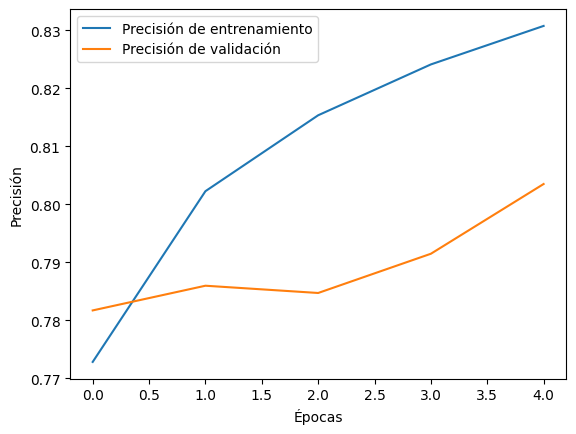

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Precisión de entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión de validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.show()



**Gráfica del loss**¨


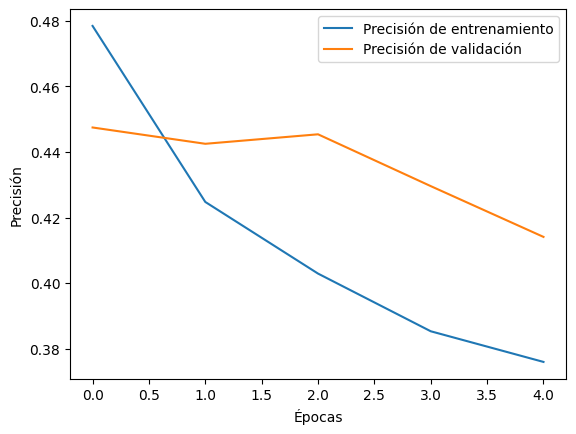

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Precisión de entrenamiento')
plt.plot(history.history['val_loss'], label='Precisión de validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()



###Evaluación del modelo

#### Matriz de confusión

Se obtienen las imágenes de prueba

In [ ]:
test_dir = '/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/test'

test_datagen = ImageDataGenerator(rescale=1.0/255.0)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 4990 images belonging to 2 classes.


Importar librerías

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import load_model


Hacer predicciones

In [ ]:
y_pred = model.predict(test_generator, verbose=1)

y_pred_classes = (y_pred > 0.5).astype("int32")

y_true = test_generator.classes

312/312 ━━━━━━━━━━━━━━━━━━━━ 296s 947ms/step


Crear matriz de confusión

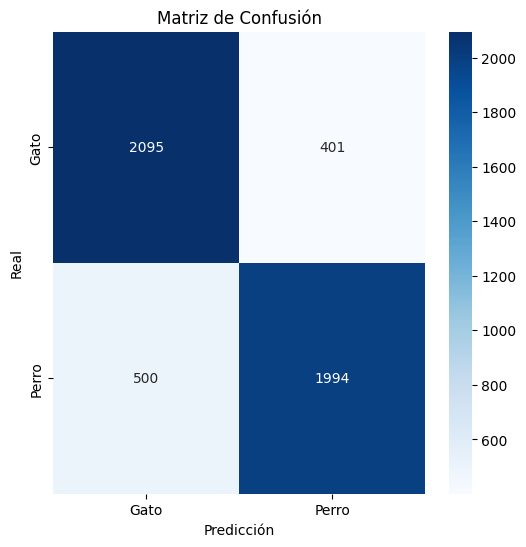

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Gato', 'Perro'], yticklabels=['Gato', 'Perro'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

####Evaluación de imágenes

Montar drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Primera evaluación

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


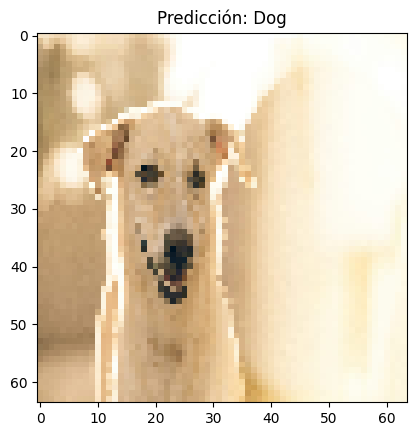

Probabilidad de gato: 33.88%
Probabilidad de perro: 66.12%


In [ ]:

import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = '/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/3imagenesprueba/imagen1.jpg'

img = image.load_img(img_path, target_size=(64, 64))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

predictions = model.predict(img_array)

# Si la predicción es mayor a 0.5, es perro, si no es gato
predicted_class_label = 'Dog' if predictions[0] > 0.5 else 'Cat'

plt.imshow(img)
plt.title(f"Predicción: {predicted_class_label}")
plt.show()

cat_probability = 1 - predictions[0]
dog_probability = predictions[0]

print(f"Probabilidad de gato: {cat_probability[0] * 100:.2f}%")
print(f"Probabilidad de perro: {dog_probability[0] * 100:.2f}%")



Segunda evaluación

Mounted at /content/drive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


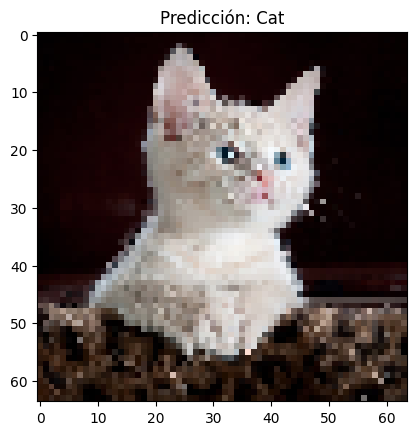

Probabilidad de gato: 98.47%
Probabilidad de perro: 1.53%


In [ ]:

import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

img_path = '/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/3imagenesprueba/imagen2.jpg'

img = image.load_img(img_path, target_size=(64, 64))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

predictions = model.predict(img_array)

# Si la predicción es mayor a 0.5, es perro, si no es gato
predicted_class_label = 'Dog' if predictions[0] > 0.5 else 'Cat'

plt.imshow(img)
plt.title(f"Predicción: {predicted_class_label}")
plt.show()

cat_probability = 1 - predictions[0]
dog_probability = predictions[0]

print(f"Probabilidad de gato: {cat_probability[0] * 100:.2f}%")
print(f"Probabilidad de perro: {dog_probability[0] * 100:.2f}%")



Tercera evaluación

Mounted at /content/drive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


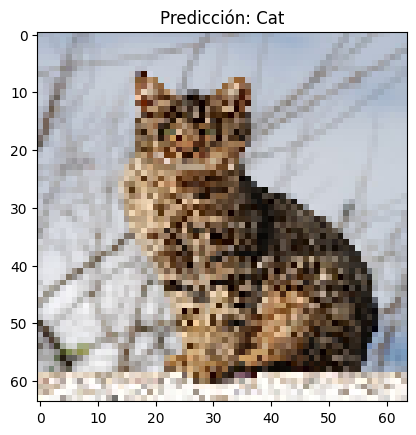

Probabilidad de gato: 81.86%
Probabilidad de perro: 18.14%


In [ ]:

import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

img_path = '/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/3imagenesprueba/imagen3.jpg'

img = image.load_img(img_path, target_size=(64, 64))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

predictions = model.predict(img_array)

# Si la predicción es mayor a 0.5, es perro, si no es gato
predicted_class_label = 'Dog' if predictions[0] > 0.5 else 'Cat'

plt.imshow(img)
plt.title(f"Predicción: {predicted_class_label}")
plt.show()

cat_probability = 1 - predictions[0]
dog_probability = predictions[0]

print(f"Probabilidad de gato: {cat_probability[0] * 100:.2f}%")
print(f"Probabilidad de perro: {dog_probability[0] * 100:.2f}%")



# Segunda arquitectura

### Obtención imágenes de entrenamiento y normalización

Para la realización del modelo se obtendrán primero las imágenes del directorio train y directorio test

Montar colab

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Obtención rutas, normalización y se define el tamaño de la imagen, tamaño de lote y épocas

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers

IMG_SIZE = (96, 96)
BATCH_SIZE = 16
EPOCHS = 7

train_dir = '/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/train'

train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=True
)



Found 15961 images belonging to 2 classes.
Found 3990 images belonging to 2 classes.


### Importar modelo

Se importa el modelo DenseNet121 para la segunda arquitectura

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(96, 96, 3))

base_model.trainable = False

model2 = tf.keras.Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model2.compile(optimizer=Adam(learning_rate=1e-5), loss='binary_crossentropy', metrics=['accuracy'])


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Creación del modelo

Se entrena el modelo con los datos train, validation y las épocas.

In [ ]:
history = model2.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    batch_size=16
)

Epoch 1/7


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


998/998 ━━━━━━━━━━━━━━━━━━━━ 3837s 4s/step - accuracy: 0.5304 - loss: 1.7201 - val_accuracy: 0.6516 - val_loss: 0.8278
Epoch 2/7
998/998 ━━━━━━━━━━━━━━━━━━━━ 723s 684ms/step - accuracy: 0.5990 - loss: 1.2608 - val_accuracy: 0.7311 - val_loss: 0.5992
Epoch 3/7
998/998 ━━━━━━━━━━━━━━━━━━━━ 677s 678ms/step - accuracy: 0.6733 - loss: 1.0087 - val_accuracy: 0.7895 - val_loss: 0.4771
Epoch 4/7
998/998 ━━━━━━━━━━━━━━━━━━━━ 687s 687ms/step - accuracy: 0.7153 - loss: 0.8352 - val_accuracy: 0.8163 - val_loss: 0.4044
Epoch 5/7
998/998 ━━━━━━━━━━━━━━━━━━━━ 681s 682ms/step - accuracy: 0.7423 - loss: 0.7429 - val_accuracy: 0.8414 - val_loss: 0.3582
Epoch 6/7
998/998 ━━━━━━━━━━━━━━━━━━━━ 680s 681ms/step - accuracy: 0.7625 - loss: 0.6854 - val_accuracy: 0.8556 - val_loss: 0.3267
Epoch 7/7
998/998 ━━━━━━━━━━━━━━━━━━━━ 683s 682ms/step - accuracy: 0.7853 - loss: 0.6189 - val_accuracy: 0.8662 - val_loss: 0.3034


####Graficación de accuracy y loss

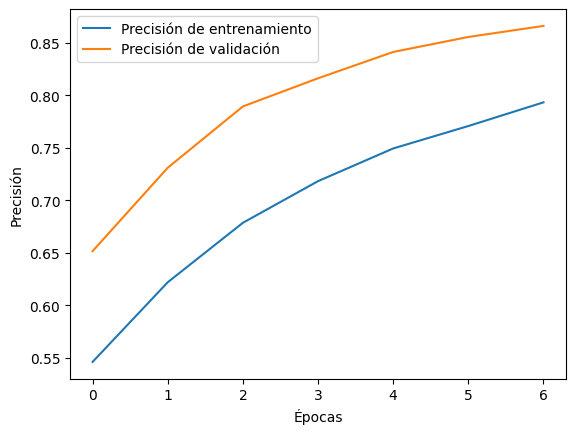

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Precisión de entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión de validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.show()

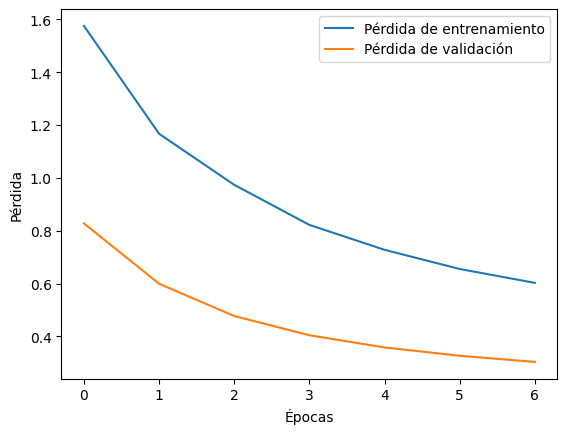

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()



###Evaluación del modelo

####Matriz de confusión

Se obtienen las imágenes de prueba

In [ ]:
test_dir = '/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/Convolución avanzada/1/test'    # Ajusta según tu ruta

test_datagen = ImageDataGenerator(rescale=1.0/255.0)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 4990 images belonging to 2 classes.


Importar librerías

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import load_model


Hacer predicciones

In [ ]:

y_pred = model2.predict(test_generator, verbose=1)

y_pred_classes = (y_pred > 0.5).astype("int32")

y_true = test_generator.classes

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


312/312 ━━━━━━━━━━━━━━━━━━━━ 863s 3s/step


Crear matriz de confusión

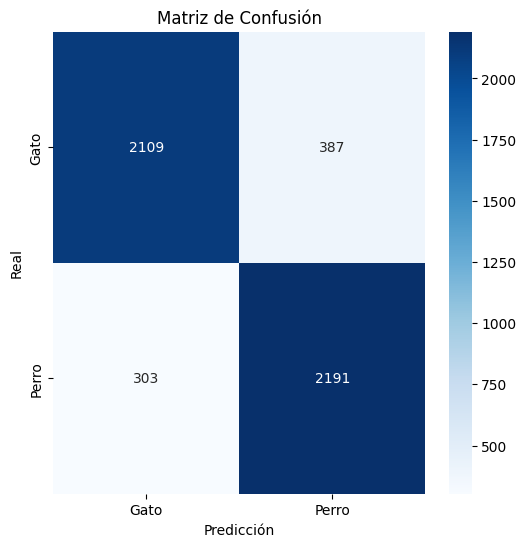

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Gato', 'Perro'], yticklabels=['Gato', 'Perro'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

####Evaluación de imágenes

Montar drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Primera evaluación

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


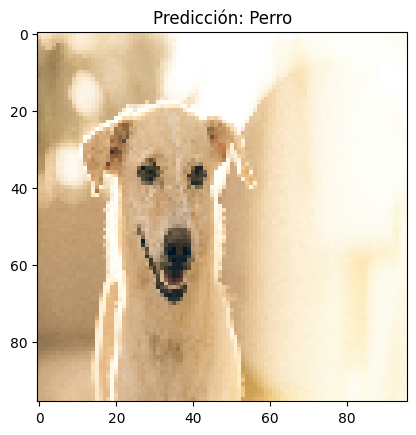

Probabilidad de gato: 0.02%
Probabilidad de perro: 99.98%


In [ ]:

import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = '/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/3imagenesprueba/imagen1.jpg'

img = image.load_img(img_path, target_size=(96, 96))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

predictions = model2.predict(img_array)

# Si la predicción es mayor a 0.5, es perro, si no es gato
predicted_class_label = 'Perro' if predictions[0] > 0.5 else 'Gato'

plt.imshow(img)
plt.title(f"Predicción: {predicted_class_label}")
plt.show()

cat_probability = 1 - predictions[0]
dog_probability = predictions[0]

print(f"Probabilidad de gato: {cat_probability[0] * 100:.2f}%")
print(f"Probabilidad de perro: {dog_probability[0] * 100:.2f}%")


Segunda evaluación

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


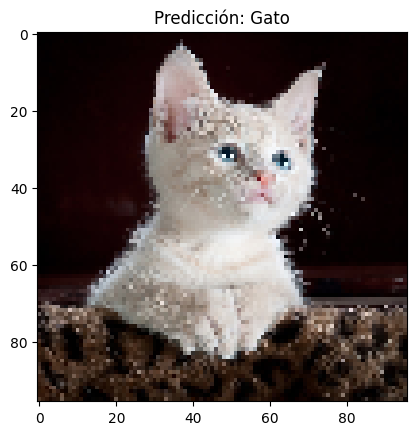

Probabilidad de gato: 99.91%
Probabilidad de perro: 0.09%


In [ ]:

import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = '/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/3imagenesprueba/imagen2.jpg'

img = image.load_img(img_path, target_size=(96, 96))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

predictions = model2.predict(img_array)

# Si la predicción es mayor a 0.5, es perro, si no es gato
predicted_class_label = 'Perro' if predictions[0] > 0.5 else 'Gato'

plt.imshow(img)
plt.title(f"Predicción: {predicted_class_label}")
plt.show()

cat_probability = 1 - predictions[0]
dog_probability = predictions[0]

print(f"Probabilidad de gato: {cat_probability[0] * 100:.2f}%")
print(f"Probabilidad de perro: {dog_probability[0] * 100:.2f}%")

Tercera evaluación

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


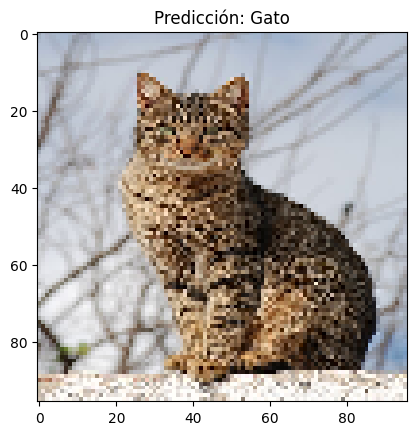

Probabilidad de gato: 99.95%
Probabilidad de perro: 0.05%


In [ ]:

import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = '/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/3imagenesprueba/imagen3.jpg'

img = image.load_img(img_path, target_size=(96, 96))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

predictions = model2.predict(img_array)

# Si la predicción es mayor a 0.5, es perro, si no es gato
predicted_class_label = 'Perro' if predictions[0] > 0.5 else 'Gato'

plt.imshow(img)
plt.title(f"Predicción: {predicted_class_label}")
plt.show()

cat_probability = 1 - predictions[0]
dog_probability = predictions[0]

print(f"Probabilidad de gato: {cat_probability[0] * 100:.2f}%")
print(f"Probabilidad de perro: {dog_probability[0] * 100:.2f}%")